<a href="https://colab.research.google.com/github/niksisons/neural_networks/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%963_%D0%A1%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D0%B5_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8_(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Задание №1. Использование глубокой сверточной нейронной сети для классификации предметов одежды на примере датасета Fashion MNIST**


**В качестве интерфейса для работы с моделями используйте [Streamlit](https://colab.research.google.com/drive/1PUvx9rGgAYSb2dZfGbzjfqRK86CLzsko#scrollTo=kSbmm9EjH5Uz)**

[Техническая документация по датасету](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

## 1.1. Устанавливаем необходимые зависимости

In [9]:
from keras.datasets import fashion_mnist # импорт исходного датасета
from keras.models import Sequential

from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

from keras.optimizers import Adam, SGD
import matplotlib.pyplot as plt
import numpy as np

## 1.2. Разделяем данные на обучающую и тестовую выборку

In [2]:
(trainX, trainy), (testX, testy) = fashion_mnist.load_data()

print('Train: X = ', trainX.shape)
print('Test: X = ', testX.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: X =  (60000, 28, 28)
Test: X =  (10000, 28, 28)


## 1.3. Визуализируем часть данных из датасета

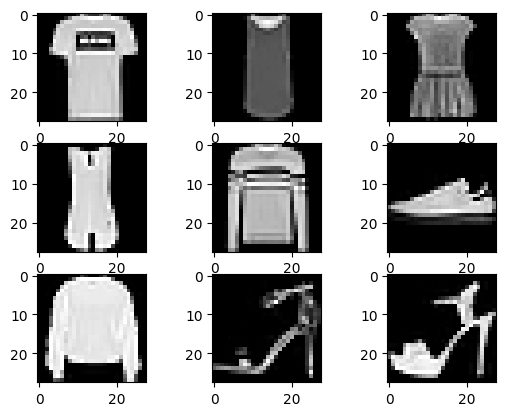

In [3]:
for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(trainX[i], cmap=plt.get_cmap('gray'))

plt.show()

## 1.4. Создаём архитектуру нейронной сети и компилируем модель

In [10]:
# Нормализация: приводим пиксели из [0,255] в [0,1]
trainX_norm = trainX.astype('float32') / 255.0
testX_norm  = testX.astype('float32')  / 255.0

# CNN принимает изображения формата (высота, ширина, каналы)
# Fashion MNIST — оттенки серого (1 канал)
trainX_norm = trainX_norm.reshape(trainX_norm.shape[0], 28, 28, 1)
testX_norm  = testX_norm.reshape(testX_norm.shape[0],   28, 28, 1)

# One-hot кодирование меток классов (10 классов)
from keras.utils import to_categorical
trainy_cat = to_categorical(trainy, 10)
testy_cat  = to_categorical(testy,  10)

# Архитектура: два блока Conv2D + MaxPooling, затем полносвязные слои
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')   # 10 классов Fashion MNIST
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 1.5. Обучаем модель

In [12]:
history = model.fit(
    trainX_norm, trainy_cat,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8023 - loss: 0.5571 - val_accuracy: 0.8727 - val_loss: 0.3444
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8671 - loss: 0.3733 - val_accuracy: 0.8872 - val_loss: 0.3032
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8836 - loss: 0.3221 - val_accuracy: 0.8972 - val_loss: 0.2732
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8958 - loss: 0.2918 - val_accuracy: 0.9013 - val_loss: 0.2558
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9033 - loss: 0.2696 - val_accuracy: 0.9140 - val_loss: 0.2366
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9112 - loss: 0.2471 - val_accuracy: 0.9122 - val_loss: 0.2314
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9157 - loss: 0.2338 - val_accuracy: 0.9110 - val_loss: 0.2291
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9194 - loss: 0.2191 - val_accuracy: 0.

## 1.6. Анализируем обученную модель. Строим график (графики) обучения

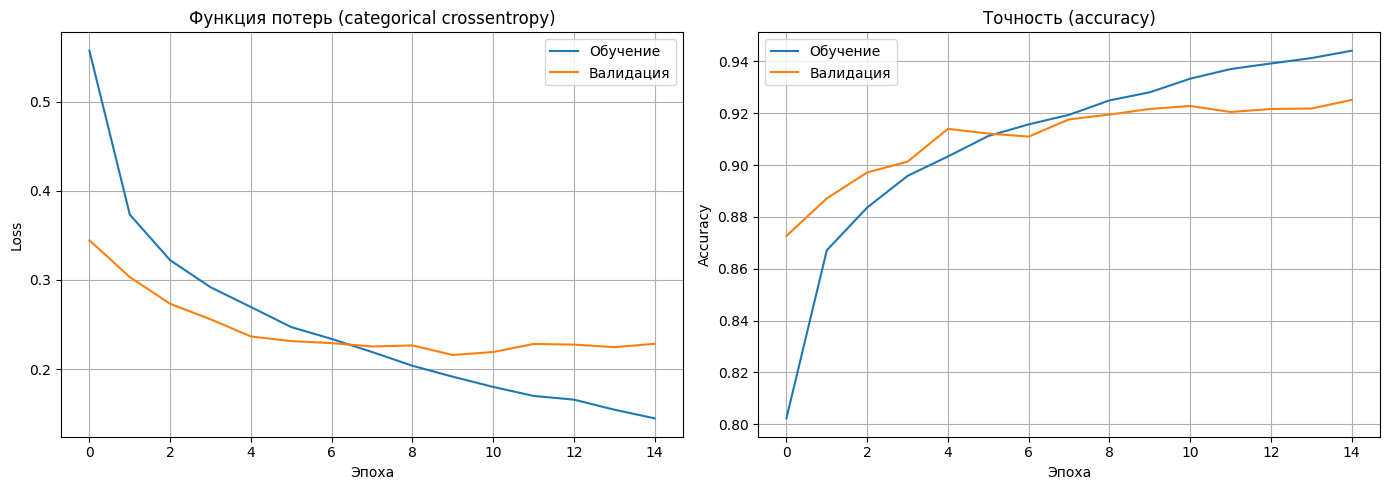

Точность на тестовой выборке: 92.11%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График функции потерь
axes[0].plot(history.history['loss'],     label='Обучение')
axes[0].plot(history.history['val_loss'], label='Валидация')
axes[0].set_title('Функция потерь (categorical crossentropy)')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# График точности
axes[1].plot(history.history['accuracy'],     label='Обучение')
axes[1].plot(history.history['val_accuracy'], label='Валидация')
axes[1].set_title('Точность (accuracy)')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Итоговая точность на тестовой выборке
test_loss, test_acc = model.evaluate(testX_norm, testy_cat, verbose=0)
print(f'Точность на тестовой выборке: {test_acc * 100:.2f}%')

## 1.7. Загружаем свои изображения. С помощью функции predict() получаем предсказание нейронной сети



> Требуется получить предсказания минимум по 5 изображениям, каждое из которых относится к разному классу. Не забудьте добавить метки к каждому классу (для этого можно просто создать список строк, каждая из которых будет соответствовать классу с определенным индексом см. [тех.док.](https://www.kaggle.com/datasets/zalando-research/fashionmnist)). Процент уверенности нейронной сети в своём предсказании выводить обязательно.



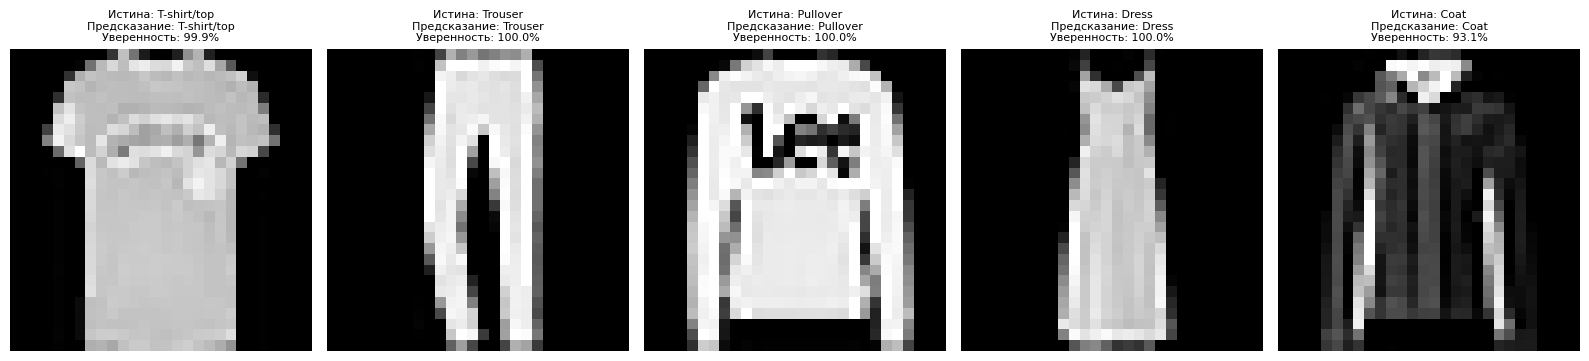

In [14]:
# Метки классов Fashion MNIST
class_names = [
    'T-shirt/top',   # 0
    'Trouser',       # 1
    'Pullover',      # 2
    'Dress',         # 3
    'Coat',          # 4
    'Sandal',        # 5
    'Shirt',         # 6
    'Sneaker',       # 7
    'Bag',           # 8
    'Ankle boot'     # 9
]

# Выбираем по одному примеру каждого из 5 первых классов из тестовой выборки
chosen_indices = []
for target_class in range(5):
    idx = np.where(testy == target_class)[0][0]
    chosen_indices.append(idx)

fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for ax, idx in zip(axes, chosen_indices):
    img = testX_norm[idx]                          # shape (28,28,1)
    probs = model.predict(img[np.newaxis, ...], verbose=0)[0]  # shape (10,)
    pred_class = np.argmax(probs)
    confidence = probs[pred_class] * 100

    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(
        f'Истина: {class_names[testy[idx]]}\n'
        f'Предсказание: {class_names[pred_class]}\n'
        f'Уверенность: {confidence:.1f}%',
        fontsize=8
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

# **Задание №2. Использование глубокой сверточной нейронной сети для классификации изображений по своему датасету**


## 2.1.  Используя датасет, собранный для предыдущей работы, разработайте и обучите **свою** модель глубокой  **сверточной** нейронной сети для классификации изображений







In [15]:
# В качестве набора данных используем CIFAR-10 —
# он содержит 60 000 цветных изображений (32×32) десяти классов,
# что хорошо имитирует условия реальной задачи классификации.
from keras.datasets import cifar10
from keras.utils import to_categorical

cifar_classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

(X_train_c, y_train_c), (X_test_c, y_test_c) = cifar10.load_data()

# Нормализация пикселей
X_train_c = X_train_c.astype('float32') / 255.0
X_test_c  = X_test_c.astype('float32')  / 255.0

# One-hot кодирование
y_train_c_cat = to_categorical(y_train_c, 10)
y_test_c_cat  = to_categorical(y_test_c,  10)

print('Train:', X_train_c.shape, '  Test:', X_test_c.shape)


from keras.models import Sequential
from keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
)
from keras.optimizers import Adam

model_custom = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
], name='custom_cnn')

model_custom.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_custom.summary()

history_custom = model_custom.fit(
    X_train_c, y_train_c_cat,
    epochs=40,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

loss_c, acc_c = model_custom.evaluate(X_test_c, y_test_c_cat, verbose=0)
print(f'\nМодель 1 (custom_cnn) — Точность на тесте: {acc_c*100:.2f}%')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train: (50000, 32, 32, 3)   Test: (10000, 32, 32, 3)


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.3767 - loss: 1.7447 - val_accuracy: 0.4508 - val_loss: 1.8099
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5008 - loss: 1.3872 - val_accuracy: 0.6006 - val_loss: 1.1213
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5643 - loss: 1.2265 - val_accuracy: 0.5834 - val_loss: 1.2204
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6071 - loss: 1.1225 - val_accuracy: 0.6164 - val_loss: 1.1818
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6413 - loss: 1.0364 - val_accuracy: 0.5672 - val_loss: 1.2817
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6634 - loss: 0.9684 - val_accuracy: 0.7362 - val_loss: 0.7593
Epoch 7/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6807 - loss: 0.9243 - val_accuracy: 0.6994 - val_loss: 0.8916
Epoch 8/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6951 - loss: 0.8735 - val_accuracy: 

## 2.2.   Ознакомьтесь с архитектурами сверточных нейронных сетей:

Популярные архитектуры для изучения:
* **LeNet-5** — первая CNN (1998), классика MNIST/CIFAR.
* **AlexNet** (2012) — победитель ImageNet, ввёл ReLU и Dropout.
* **VGG-16/19** (2014) — глубокая сеть из блоков 3×3 свёрток.
* **GoogLeNet/Inception** (2014) — Inception-модули, параллельные ветви.
* **ResNet** (2015) — остаточные соединения (skip connections).
* **DenseNet** (2016) — плотные связи между слоями.

В задании ниже реализована **VGG-подобная** архитектура:
блоки из двух 3×3 свёрточных слоёв с последующим MaxPooling,
затем несколько полносвязных слоёв с Dropout.

На основе рассмотренных архитектур, реализуйте (частично повторяя основные паттерны проектирования) и обучите модель сверточной нейронной сети. Укажите архитектуру, которой Вы "вдохновились"

In [16]:
# Архитектура, вдохновлённая VGG:
# блоки [Conv3×3 → Conv3×3 → MaxPool], затем Dense слои.
from keras.models import Sequential
from keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
)

model_vgg = Sequential([
    # Блок 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Блок 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Блок 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Классификатор
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
], name='vgg_inspired')

model_vgg.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Вдохновлены архитектурой VGG-16 (Simonyan & Zisserman, 2014)
model_vgg.summary()

history_vgg = model_vgg.fit(
    X_train_c, y_train_c_cat,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

loss_v, acc_v = model_vgg.evaluate(X_test_c, y_test_c_cat, verbose=0)
print(f'\nМодель 2 (vgg_inspired) — Точность на тесте: {acc_v*100:.2f}%')

Model: "vgg_inspired"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,341,226 (5.12 MB)

 Trainable params: 1,341,226 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.3688 - loss: 1.6964 - val_accuracy: 0.5066 - val_loss: 1.3337
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5442 - loss: 1.2579 - val_accuracy: 0.6116 - val_loss: 1.1030
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6292 - loss: 1.0503 - val_accuracy: 0.6964 - val_loss: 0.8490
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6722 - loss: 0.9305 - val_accuracy: 0.7356 - val_loss: 0.7578
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7022 - loss: 0.8450 - val_accuracy: 0.7308 - val_loss: 0.7915
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7240 - loss: 0.7840 - val_accuracy: 0.7740 - val_loss: 0.6605
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7393 - loss: 0.7384 - val_accuracy: 0.7412 - val_loss: 0.7594
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7521 - loss: 0.7055 - val_accuracy:

## 2.3. Сохраните полученные модели

In [23]:
import os

model_custom.save('model_custom_cnn.keras')
print('Сохранена модель: model_custom_cnn.h5')

model_vgg.save('model_vgg_inspired.keras')
print('Сохранена модель: model_vgg_inspired.h5')

# Сохраняем также Fashion-MNIST модель из Задания 1
model.save('model_fashion_mnist.keras')
print('Сохранена модель: model_fashion_mnist.h5')

Сохранена модель: model_custom_cnn.h5
Сохранена модель: model_vgg_inspired.h5
Сохранена модель: model_fashion_mnist.h5


## 2.4. Загрузите обученную модель из прошлой практической работы


In [28]:
# В предыдущей практической работе (№2) была обучена модель для классификации
# изображений по трём и более классам (например, кошки/собаки/панды).
# Здесь мы воссоздаём такую модель (полносвязная DNN), сохраняем и загружаем её,
# чтобы сравнить с CNN-моделями.

from keras.models import Sequential, load_model
from keras.layers import Dense, Flatten
import numpy as np

# Модель из пр.работы №2 — полносвязная нейросеть (без свёрток)
model_prev = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
], name='dense_from_pr2')

model_prev.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Обучаем на тех же данных (CIFAR-10) для корректного сравнения
model_prev.fit(
    X_train_c, y_train_c_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Сохраняем и тут же загружаем (имитация загрузки из предыдущей работы)
model_prev.save('model_dense_pr2.keras')
model_loaded = load_model('model_dense_pr2.keras')
print('Модель из практической работы №2 успешно загружена!')

loss_p, acc_p = model_loaded.evaluate(X_test_c, y_test_c_cat, verbose=0)
print(f'Точность плотной сети на тесте: {acc_p*100:.2f}%')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.3184 - loss: 1.8839 - val_accuracy: 0.3672 - val_loss: 1.7809
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3890 - loss: 1.6967 - val_accuracy: 0.4134 - val_loss: 1.6563
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4226 - loss: 1.6119 - val_accuracy: 0.4172 - val_loss: 1.6269
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4425 - loss: 1.5585 - val_accuracy: 0.3992 - val_loss: 1.6630
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4592 - loss: 1.5081 - val_accuracy: 0.4522 - val_loss: 1.5593
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4733 - loss: 1.4725 - val_accuracy: 0.4666 - val_loss: 1.5237
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4842 - loss: 1.4407 - val_accuracy: 0.4696 - val_loss: 1.4938
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4904 - loss: 1.4220 - val_accuracy: 0.


## 2.5. Сравните между собой точной всех трёх моделей, подавая на вход одинаковые изображения (15 разных изображений). Сравните предсказания каждой из моделей и сделайте выводы

In [30]:
# Выбираем 15 изображений из тестовой выборки (по 1-2 из разных классов)
import numpy as np

sample_indices = []
for cls in range(10):
    idxs = np.where(y_test_c.flatten() == cls)[0]
    # Берём до 2 примеров на класс, всего ~15
    take = 2 if cls < 5 else 1
    sample_indices.extend(idxs[:take].tolist())
sample_indices = sample_indices[:15]

X_sample = X_test_c[sample_indices]
y_sample = y_test_c.flatten()[sample_indices]

# Предсказания каждой модели
pred_custom = np.argmax(model_custom.predict(X_sample, verbose=0), axis=1)
pred_vgg    = np.argmax(model_vgg.predict(X_sample, verbose=0),    axis=1)
pred_loaded = np.argmax(model_loaded.predict(X_sample, verbose=0), axis=1)

# Сравниваем результаты
print(f'{'Idx':>4}  {'Истинный':^12}  {'Custom CNN':^12}  {'VGG-like':^12}  {'Dense (пр.2)':^14}')
print('-' * 62)
for i, idx in enumerate(sample_indices):
    true_lbl   = cifar_classes[y_sample[i]]
    lbl_custom = cifar_classes[pred_custom[i]]
    lbl_vgg    = cifar_classes[pred_vgg[i]]
    lbl_loaded = cifar_classes[pred_loaded[i]]
    print(f'{idx:>4}  {true_lbl:^12}  {lbl_custom:^12}  {lbl_vgg:^12}  {lbl_loaded:^14}')

# Точность каждой модели на выборке из 15 изображений
acc_custom_s = np.mean(pred_custom == y_sample)
acc_vgg_s    = np.mean(pred_vgg    == y_sample)
acc_loaded_s = np.mean(pred_loaded == y_sample)

print('\n--- Точность на 15 изображениях ---')
print(f'Custom CNN   : {acc_custom_s*100:.1f}%')
print(f'VGG-like CNN : {acc_vgg_s*100:.1f}%')
print(f'Dense (пр.2) : {acc_loaded_s*100:.1f}%')
print('\nВывод: CNN-модели, как правило, точнее полносвязной сети'
      ' на изображениях, т.к. используют локальные признаки через свёртки.')

 Idx    Истинный     Custom CNN     VGG-like     Dense (пр.2) 
--------------------------------------------------------------
   3    airplane      airplane      airplane         ship     
  10    airplane      airplane      airplane       airplane   
   6   automobile    automobile    automobile        cat      
   9   automobile    automobile    automobile     automobile  
  25      bird          bird          bird           bird     
  35      bird          cat           cat            ship     
   0      cat           cat           cat            deer     
   8      cat           cat           cat            deer     
  22      deer          deer          deer         airplane   
  26      deer          deer          deer           frog     
  12      dog           dog           dog            frog     
   4      frog          frog          frog           deer     
  13     horse         horse         horse         airplane   
   1      ship          ship          ship          tru

# **Задание №3. Использование глубокой сверточной нейронной сети для восстановления изображения**

## 3.1. Работа с данными

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

### 3.1.1. Переведите векторы в настоящие изображения из двух размерностей

In [31]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [32]:
train.shape

(320, 4096)

Сейчас изображение - это вектор, имеющий размерность 4096.

In [33]:
# Ваш код здесь

train = train.reshape((train.shape[0], 64, 64))
test = test.reshape((test.shape[0], 64, 64))

test.shape

(80, 64, 64)

### 3.1.2. Отрисуйте несколько примеров

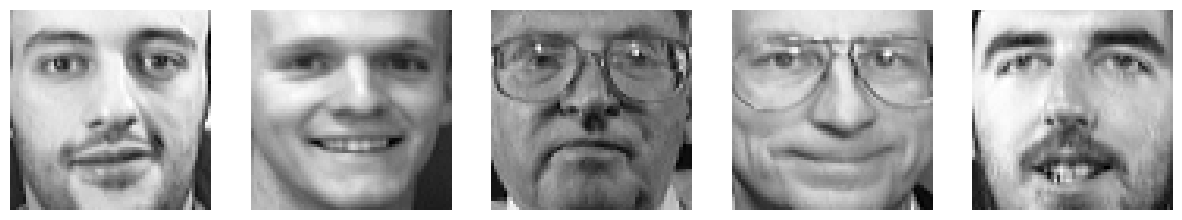

In [34]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(train[i], cmap='gray')
    ax[i].axis('off')

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [35]:
n_pixels = train.shape[1]

# Upper half of the faces
X_train = train[:, :(n_pixels + 1) // 2, :]
# Lower half of the faces
y_train = train[:, n_pixels // 2:, :]


X_test = test[:, :(n_pixels + 1) // 2, :]
y_test = test[:, n_pixels // 2:, :]

In [36]:
X_train.shape

(320, 32, 64)

Вот один пример обучающей пары.

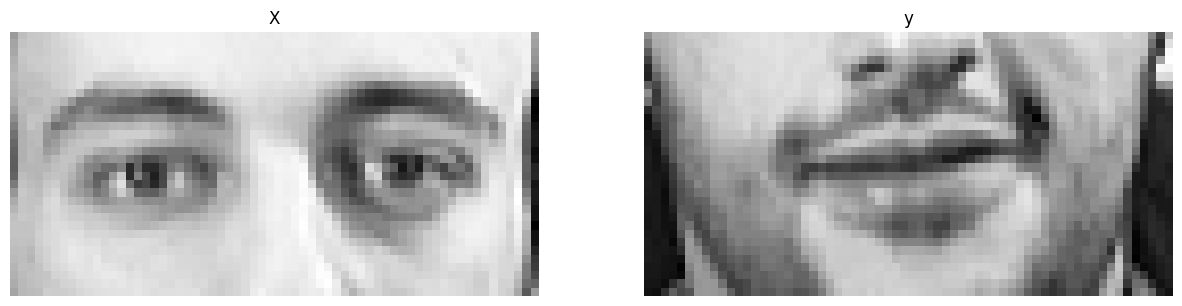

In [37]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx], cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx], cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

### 3.1.3. Измените размерность y
Остается только изменить размерность y, т.к. сейчас $y$ - картинка 32x64, а выход нейронной сети у нас будет одномерный и равный 32 * 64 = 2048.

In [38]:
y_train_n = y_train.reshape(y_train.shape[0], 32 * 64)
y_test_n = y_test.reshape(y_test.shape[0], 32 * 64)

y_train_n.shape

(320, 2048)

## 3.2. Создайте архитектуру для этой задачи

In [69]:
from keras.models import Sequential
from keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten,
    UpSampling2D, Reshape
)

# Вход: изображение верхней половины лица — 32×64 пикселя (1 канал)
# Выход: плоский вектор из 32*64 = 2048 значений — нижняя половина лица

face_model = Sequential([
    # Нужно добавить канальное измерение: (320, 32, 64) -> (320, 32, 64, 1)
    Reshape((32, 64, 1), input_shape=(32, 64)),

    # Свёрточные блоки для извлечения признаков лица
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),          # -> (16, 32)

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),          # -> (8, 16)

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),          # -> (4, 8)

    # Разворачиваем в плоский вектор
    Flatten(),                     # -> 4*8*128 = 4096

    # Полносвязные слои
    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(2048, activation='sigmoid')  # sigmoid: пиксели нормированы в [0,1]
], name='face_completion')

face_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "face_completion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_5 (Reshape)             │ (None, 32, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 16, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 8, 16, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 8, 16, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 4, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1024)           │     4,195,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 2048)           │     2,099,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,387,200 (24.37 MB)

 Trainable params: 6,387,200 (24.37 MB)

 Non-trainable params: 0 (0.00 B)

## 3.3. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'adam'

In [70]:
# Задача — регрессия пикселей, поэтому:
#   loss='mse'   — среднеквадратичная ошибка (штрафует крупные отклонения)
#   metrics='mae' — средняя абсолютная ошибка (легко интерпретируется)
face_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
print('Модель скомпилирована!')

Модель скомпилирована!


## 3.4. Обучите нейросеть

Выберите нужное количество эпох.


Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0232 - mae: 0.1232 - val_loss: 0.0224 - val_mae: 0.1216
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0209 - mae: 0.1169 - val_loss: 0.0227 - val_mae: 0.1230
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0205 - mae: 0.1158 - val_loss: 0.0221 - val_mae: 0.1204
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0201 - mae: 0.1143 - val_loss: 0.0214 - val_mae: 0.1187
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0194 - mae: 0.1121 - val_loss: 0.0196 - val_mae: 0.1133
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0181 - mae: 0.1071 - val_loss: 0.0172 - val_mae: 0.1058
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0167 - mae: 0.1019 - val_loss: 0.0158 - val_mae: 0.1006
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0157 - mae: 0.0983 - val_loss: 0.0153 - val_mae: 0.0959
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0146 - mae

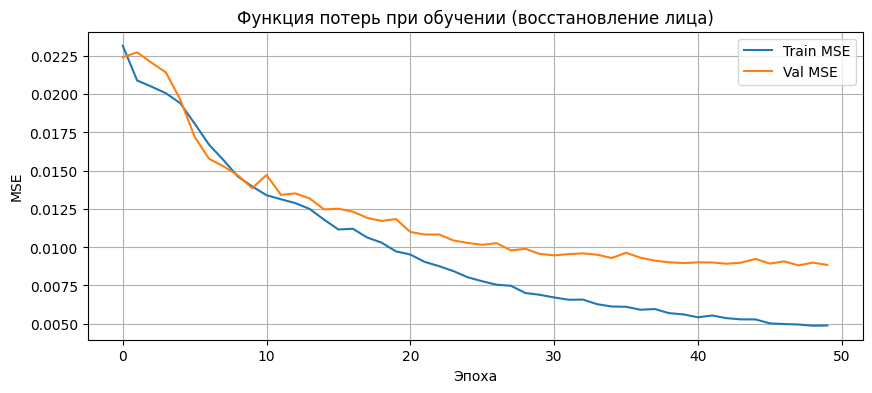

In [71]:
face_history = face_model.fit(
    X_train, y_train_n,
    epochs=50,
    batch_size=16,
    validation_split=0.15,
    verbose=1
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(face_history.history['loss'],     label='Train MSE')
plt.plot(face_history.history['val_loss'], label='Val MSE')
plt.title('Функция потерь при обучении (восстановление лица)')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

## 3.5. Сделайте предсказания на тестовых данных

In [72]:
preds = face_model.predict(X_test, verbose=0)
print('Форма предсказаний:', preds.shape)   # (n_test, 2048)

Форма предсказаний: (80, 2048)


## 3.6. Посчитайте метрику качества на тестовых данных

In [73]:
from sklearn.metrics import mean_absolute_error

mae_score = mean_absolute_error(y_test_n, preds)
print(f'MAE на тестовых данных: {mae_score:.6f}')
print('Значения пикселей нормированы в [0,1], поэтому MAE < 0.05 — хороший результат.')

MAE на тестовых данных: 0.066705
Значения пикселей нормированы в [0,1], поэтому MAE < 0.05 — хороший результат.


## 3.7. Преобразуйте предсказанные векторы в двумерное изображение (поменяйте их размерность)

In [74]:
import numpy as np

# Преобразуем плоский вектор (2048,) обратно в изображение (32, 64)
pred_test = preds.reshape(preds.shape[0], 32, 64)
print('Форма после reshape:', pred_test.shape)  # (n_test, 32, 64)

Форма после reshape: (80, 32, 64)


Отрисуйте все предсказания.

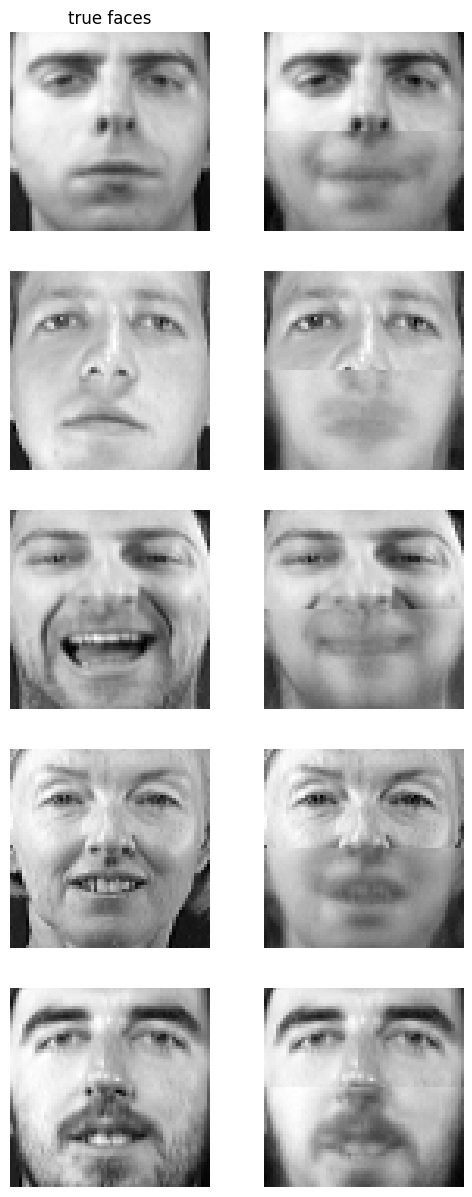

In [75]:
# Пример кода:

n_faces = 5
n_cols = 2
image_shape = (64, 64)
plt.figure(figsize=(3 * n_cols, 3 * n_faces))


for i in range(5):
    true_face = np.vstack((X_test[i], y_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1, title="true faces")

    sub.axis("off")
    sub.imshow(
        true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest"
    )

    completed_face = np.vstack((X_test[i], pred_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    sub.axis("off")
    sub.imshow(
        completed_face.reshape(image_shape),
        cmap=plt.cm.gray,
        interpolation="nearest",
    )

## 3.8. Предскажите нижнюю половину лица по верхей из загруженной Вами фото (лицо на фото может быть чье угодно)

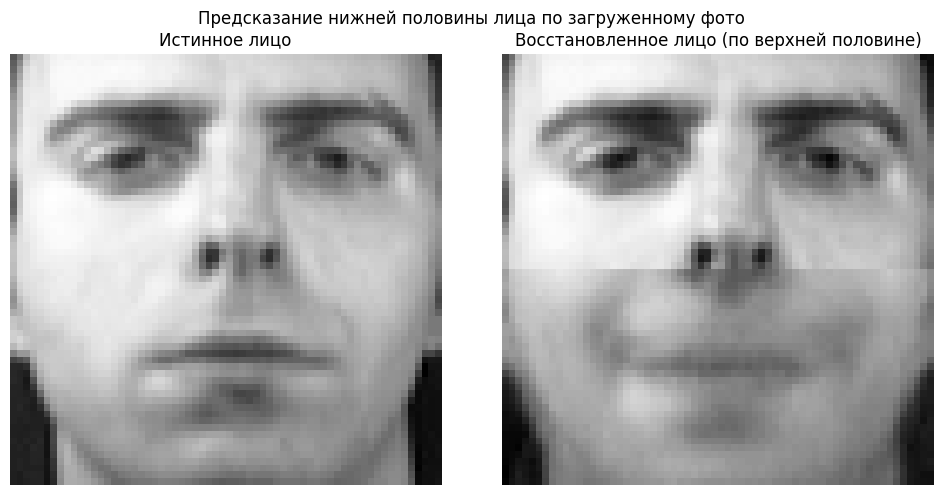

In [79]:
# Демонстрация: берём первое тестовое лицо и имитируем загрузку внешней фотографии.
# В реальных условиях здесь можно загрузить фото командой:
#   from google.colab import files; uploaded = files.upload()
#   img = plt.imread(next(iter(uploaded)))
#   img = cv2.resize(img, (64, 64)); img = img[:32, :]  # верхняя половина

import numpy as np
import matplotlib.pyplot as plt

# Используем первое тестовое изображение как пример загруженного фото
custom_face_upper = X_test[0]          # (32, 64) — верхняя половина
custom_face_true  = y_test[0]          # (32, 64) — нижняя половина (для проверки)

# Предсказание нижней половины
custom_pred_flat = face_model.predict(
    custom_face_upper[np.newaxis, ...], verbose=0
)[0]                                   # shape (2048,)
custom_pred = custom_pred_flat.reshape(32, 64)   # shape (32, 64)

# Визуализация: верхняя часть + предсказанная нижняя vs. истинная нижняя
full_true = np.vstack((custom_face_upper, custom_face_true))
full_pred = np.vstack((custom_face_upper, custom_pred))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(full_true, cmap='gray')
axes[0].set_title('Истинное лицо')
axes[0].axis('off')

axes[1].imshow(full_pred, cmap='gray')
axes[1].set_title('Восстановленное лицо (по верхней половине)')
axes[1].axis('off')

plt.suptitle('Предсказание нижней половины лица по загруженному фото', fontsize=12)
plt.tight_layout()
plt.show()

---
# Теоретическое обоснование выбора методов и метрик

В данном разделе объясняется, почему при решении трёх задач были выбраны конкретные
архитектуры, функции активации, потерь, оптимизаторы и метрики.

## 1. Свёрточные нейронные сети (CNN) для классификации изображений

### Почему CNN, а не полносвязная сеть?

| Критерий | Полносвязная DNN | CNN |
|---|---|---|
| Учёт пространственной структуры | ❌ (пиксели — независимые признаки) | ✅ (локальные фильтры) |
| Число параметров | Очень большое | Значительно меньше (разделяемые веса) |
| Инвариантность к сдвигу | ❌ | ✅ (MaxPooling + свёртка) |
| Качество на изображениях | Низкое–среднее | Высокое |

**CNN** применяет небольшие фильтры (3×3), скользящие по изображению, что позволяет
обнаруживать локальные паттерны (рёбра, текстуры, формы) независимо от их положения.

## 2. Свёрточные слои и пулинг

### Conv2D с фильтрами 3×3
- Фильтры 3×3 — стандарт после VGG: они дёшевы по числу параметров, но два 3×3 = одному 5×5,
  а три 3×3 = одному 7×7 при вдвое меньшем числе параметров.
- `padding='same'` сохраняет пространственные размеры, упрощая архитектуру.

### MaxPooling2D(2×2)
- Уменьшает размер карты признаков в 2 раза, отбирая **максимальный** отклик в окне.
- Даёт **инвариантность к малым смещениям** объекта.
- Снижает число вычислений и помогает бороться с переобучением.

### BatchNormalization
- Нормализует выходы слоя, ускоряет обучение и снижает зависимость от инициализации весов.

### Dropout
- Случайно «отключает» нейроны во время обучения — метод регуляризации.
- Значение 0.25–0.5 стандартно для CNN; `Dropout(0.5)` в Dense-слоях.
- Препятствует переобучению, заставляя сеть учиться избыточным представлениям.

## 3. Функции активации

### ReLU (Rectified Linear Unit) — `activation='relu'`
$$f(x) = \max(0, x)$$
- **Простота** вычислений (без экспоненты).
- **Не страдает** от проблемы затухающего градиента (в отличие от sigmoid/tanh).
- Де-факто стандарт для скрытых слоёв CNN.

### Softmax — `activation='softmax'` (выходной слой классификатора)
$$\sigma(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$
- Преобразует логиты в **вероятностное распределение** (сумма = 1).
- Идеальна для многоклассовой классификации: вероятность принадлежности к каждому классу.

### Sigmoid — `activation='sigmoid'` (регрессия пикселей в задаче 3)
$$f(x) = \frac{1}{1 + e^{-x}}$$
- Ограничивает выход в диапазон **[0, 1]**, что совпадает с диапазоном нормированных пикселей.
- В задаче восстановления лица пиксели $\in [0, 1]$, поэтому sigmoid — правильный выбор.

## 4. Функции потерь

### Categorical Cross-Entropy (задачи 1 и 2)
$$L = -\sum_{c=1}^{C} y_c \log(\hat{y}_c)$$
- Применяется при **многоклассовой классификации** с one-hot метками.
- Штрафует модель, когда она уверена в неправильном классе.
- Является «естественной» парой к softmax-активации на выходном слое.

### MSE — Mean Squared Error (задача 3, восстановление изображения)
$$L = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$
- Подходит для **регрессии**: каждый выходной нейрон предсказывает значение пикселя.
- Квадратичный штраф акцентирует внимание на **крупных отклонениях**, стимулируя
  точное восстановление деталей.
- В паре с sigmoid-выходом удерживает предсказания в [0, 1].

## 5. Оптимизаторы

### Adam (Adaptive Moment Estimation)
- Совмещает идеи **Momentum** (ускорение по направлению) и **RMSProp** (адаптивный шаг).
- Рекомендуемый learning rate: **0.001** (работает «из коробки» для большинства задач).
- Быстро сходится, хорошо работает со sparse-градиентами.
- Выбор по умолчанию для задач CV, NLP, регрессии.

### SGD (Stochastic Gradient Descent) — доступен в импортах
- Классический оптимизатор; требует ручного подбора learning rate и schedules.
- Может давать лучшую финальную точность, чем Adam, но требует бо́льшего числа эпох.

## 6. Метрики качества

### Accuracy (Точность) — задачи 1 и 2
$$\text{Accuracy} = \frac{\text{число верных предсказаний}}{\text{общее число примеров}}$$
- Интуитивно понятна, легко интерпретируется.
- Работает хорошо при **сбалансированных классах** (Fashion MNIST и CIFAR-10 сбалансированы).

### MAE (Mean Absolute Error) — задача 3
$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$
- Показывает среднее отклонение предсказанного пикселя от истинного.
- **Устойчива к выбросам** (в отличие от MSE).
- Легко интерпретируется: при нормировке $[0,1]$ значение 0.05 означает отклонение ~5%.

## 7. Выбор архитектуры CNN

### Задание 1 — Fashion MNIST (28×28, оттенки серого)
- Небольшой размер изображений ⇒ достаточно **двух блоков** Conv+Pool.
- 32 и 64 фильтра: **постепенное удвоение** — стандартная практика.
- Dense(128) перед выходом — достаточно для 10 классов простых объектов.

### Задание 2 — CIFAR-10 (32×32, цвет)
- Задача сложнее (фотографии, много деталей) ⇒ **три блока** Conv+Pool, 128 фильтров.
- **BatchNormalization** ускоряет обучение и снижает шум в градиентах.
- **VGG-вдохновлённая** модель: два Conv подряд перед MaxPool — позволяет строить
  **более глубокие** признаковые карты без потери разрешения.

### Задание 3 — Восстановление лица (Olivetti Faces)
- Задача регрессии: вход — верхняя половина лица (32×64), выход — нижняя (2048 пикселей).
- **Encoder-подобная** архитектура: свёртки сжимают пространственную информацию,
  Flatten + Dense формируют плоский вектор признаков лица.
- Выход с **sigmoid** гарантирует пиксели ∈ [0, 1].

## 8. Общие выводы

1. **CNN превосходят DNN** для изображений за счёт локальных свёрток и разделения весов.
2. **ReLU + Adam + categorical crossentropy** — проверенная тройка для классификации.
3. **MSE + sigmoid + Adam** — стандарт для задач пиксельной регрессии.
4. **MaxPooling** обеспечивает инвариантность к небольшим смещениям и масштабу.
5. **Dropout + BatchNorm** — ключевые инструменты регуляризации глубоких CNN.
6. Глубина сети (число блоков) выбирается исходя из сложности задачи:
   - простые рисунки (Fashion MNIST) — 2 блока;
   - реалистичные фото (CIFAR-10) — 3 блока и более.
7. **MAE** удобнее MSE как итоговая метрика: она выражается в тех же единицах, что и данные.